In [6]:
import json
import re
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})

RESULTS_PATH = Path("results/baseline-json_projection_overhead.json")

# File sizes match lazy-parsing/plot.ipynb
JSON_BID_FILE_SIZE    = 15878100724    # bytes
JSON_PERSON_FILE_SIZE = 1300941057     # bytes

def shorten(q):
    q = q.strip()
    q = re.sub(r"\s+INTO\s+\w+", "", q, flags=re.IGNORECASE)
    return re.sub(r"\s+", " ", q).strip()

def projection(q):
    m = re.match(r"SELECT\s+(.*?)\s+FROM\s+", q, flags=re.IGNORECASE)
    return m.group(1).strip() if m else "?"

def source(q):
    m = re.search(r"FROM\s+(\w+)", q, flags=re.IGNORECASE)
    return m.group(1).lower() if m else "?"

def file_size(src):
    return JSON_BID_FILE_SIZE if src == "bid" else JSON_PERSON_FILE_SIZE

with open(RESULTS_PATH) as f:
    raw = json.load(f)

rows = []
for r in raw:
    if r.get("status") != "Stopped" or not r.get("started") or not r.get("stopped"):
        continue
    started = datetime.strptime(r["started"], "%Y-%m-%d %H:%M:%S.%f")
    stopped = datetime.strptime(r["stopped"], "%Y-%m-%d %H:%M:%S.%f")
    exec_time = (stopped - started).total_seconds()
    if exec_time <= 0:
        continue
    q = shorten(r["query"])
    src = source(q)
    rows.append({
        "query": q,
        "projection": projection(q),
        "source": src,
        "threads": int(r["threads_number"]),
        "exec_time_s": exec_time,
        "throughput_MBs": file_size(src) / exec_time / (1024 * 1024),
    })

df = pd.DataFrame(rows)
print(f"records: {len(df)}")
print(f"threads: {sorted(df.threads.unique())}")
print(f"sources: {sorted(df.source.unique())}")
print("queries:")
for s in sorted(df.source.unique()):
    for q in sorted(df[df.source == s]["query"].unique()):
        print(f"  [{s}] {q}")
df.head()

records: 48
threads: [np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32), np.int64(64)]
sources: ['bid', 'person']
queries:
  [bid] SELECT auctionId FROM bid
  [bid] SELECT price FROM bid
  [bid] SELECT timestamp FROM bid
  [person] SELECT * FROM person
  [person] SELECT city FROM person
  [person] SELECT extra FROM person
  [person] SELECT id FROM person
  [person] SELECT name FROM person


,query,projection,source,threads,exec_time_s,throughput_MBs
0,SELECT name FROM person,name,person,2,11.212,110.655911
1,SELECT city FROM person,city,person,2,11.226,110.517911
2,SELECT extra FROM person,extra,person,2,11.549,107.426970
3,SELECT id FROM person,id,person,2,10.498,118.181946
4,SELECT * FROM person,*,person,2,15.058,82.393019


## Exec time per projection across threads
One subplot per source (`bid`, `person`). Lines = projections, log-log axes.

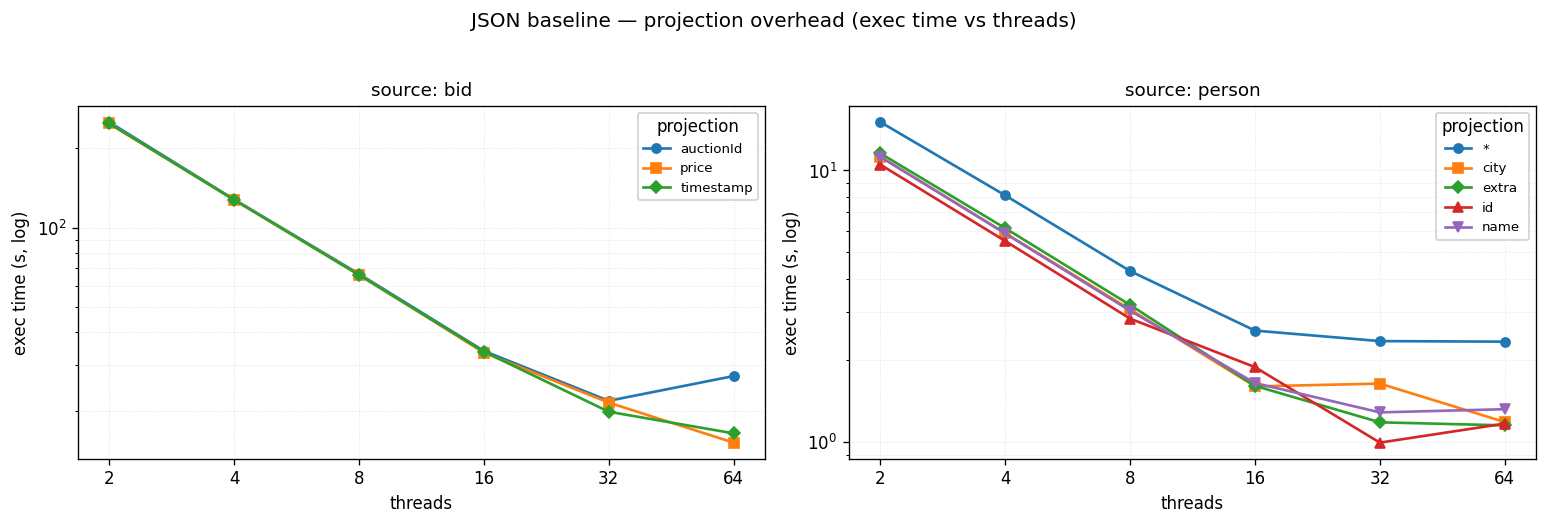

In [7]:
sources = sorted(df.source.unique())
thread_counts = sorted(df.threads.unique())
palette = plt.get_cmap("tab10").colors
markers = ["o", "s", "D", "^", "v", "P", "X", "*"]

fig, axes = plt.subplots(1, len(sources), figsize=(6.5 * len(sources), 4.2), dpi=120, sharex=True)
if len(sources) == 1:
    axes = [axes]

for ax, src in zip(axes, sources):
    sub = df[df.source == src]
    for i, proj in enumerate(sorted(sub.projection.unique())):
        vals = (sub[sub.projection == proj]
                  .groupby("threads")["exec_time_s"].median()
                  .reindex(thread_counts))
        ax.plot(thread_counts, vals.values,
                marker=markers[i % len(markers)], markersize=5.5, linewidth=1.6,
                color=palette[i % len(palette)], label=proj)
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xticks(thread_counts)
    ax.set_xticklabels(thread_counts)
    ax.set_title(f"source: {src}")
    ax.set_xlabel("threads")
    ax.set_ylabel("exec time (s, log)")
    ax.grid(True, which="both", linestyle=":", alpha=0.4)
    ax.legend(title="projection", fontsize=8, frameon=True, framealpha=0.9)

fig.suptitle("JSON baseline — projection overhead (exec time vs threads)", y=1.03)
fig.tight_layout()
plt.show()

## Grouped bars — exec time per thread count, bars = projections

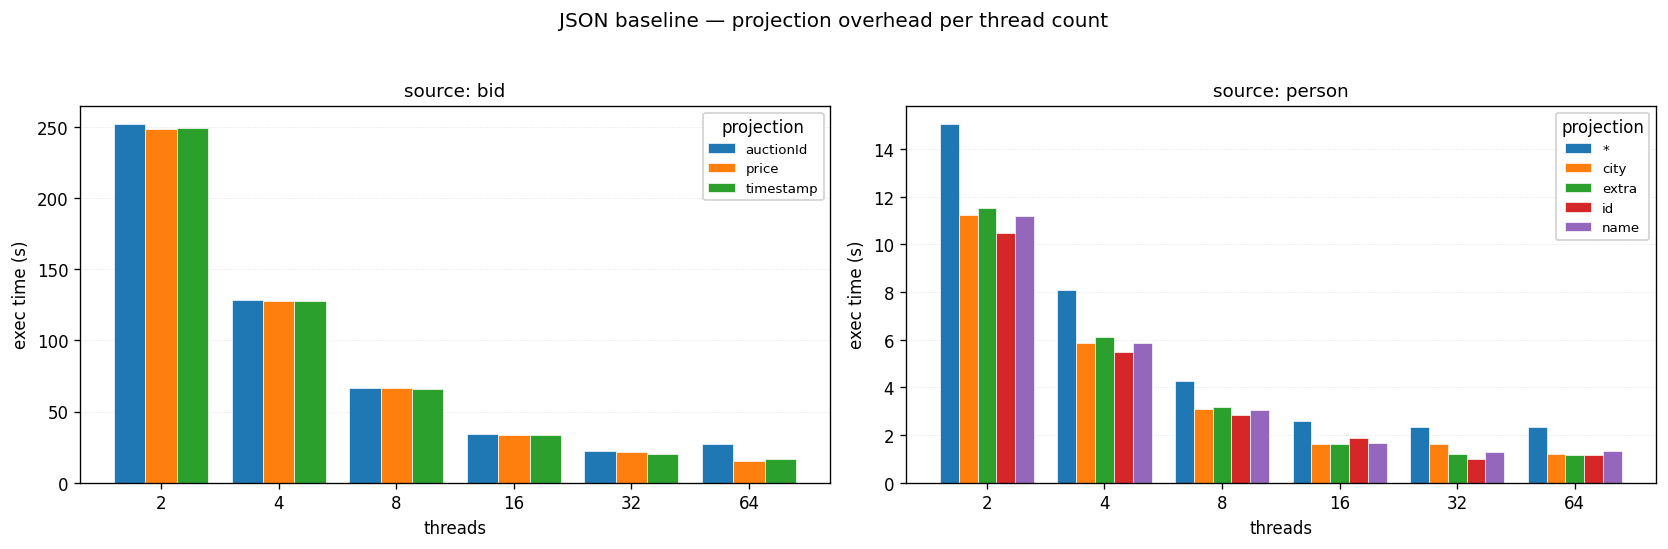

In [8]:
fig, axes = plt.subplots(1, len(sources), figsize=(7 * len(sources), 4.4), dpi=120)
if len(sources) == 1:
    axes = [axes]

for ax, src in zip(axes, sources):
    sub = df[df.source == src]
    projections = sorted(sub.projection.unique())
    n = len(projections)
    x = np.arange(len(thread_counts))
    bar_w = 0.8 / n
    for i, proj in enumerate(projections):
        vals = (sub[sub.projection == proj]
                  .groupby("threads")["exec_time_s"].median()
                  .reindex(thread_counts))
        offset = (i - (n - 1) / 2) * bar_w
        ax.bar(x + offset, vals.values, bar_w,
               label=proj, color=palette[i % len(palette)],
               edgecolor="white", linewidth=0.4)
    ax.set_xticks(x)
    ax.set_xticklabels(thread_counts)
    ax.set_title(f"source: {src}")
    ax.set_xlabel("threads")
    ax.set_ylabel("exec time (s)")
    ax.grid(True, axis="y", linestyle=":", alpha=0.4)
    ax.set_axisbelow(True)
    ax.legend(title="projection", fontsize=8, frameon=True, framealpha=0.9)

fig.suptitle("JSON baseline — projection overhead per thread count", y=1.03)
fig.tight_layout()
plt.show()

## Throughput (MB/s) per projection — grouped bars
Throughput = `file_size / exec_time` using the on-disk JSON file size (bid: 15.88 GB, person: 1.30 GB). Same style as `lazy-parsing/plot.ipynb`.

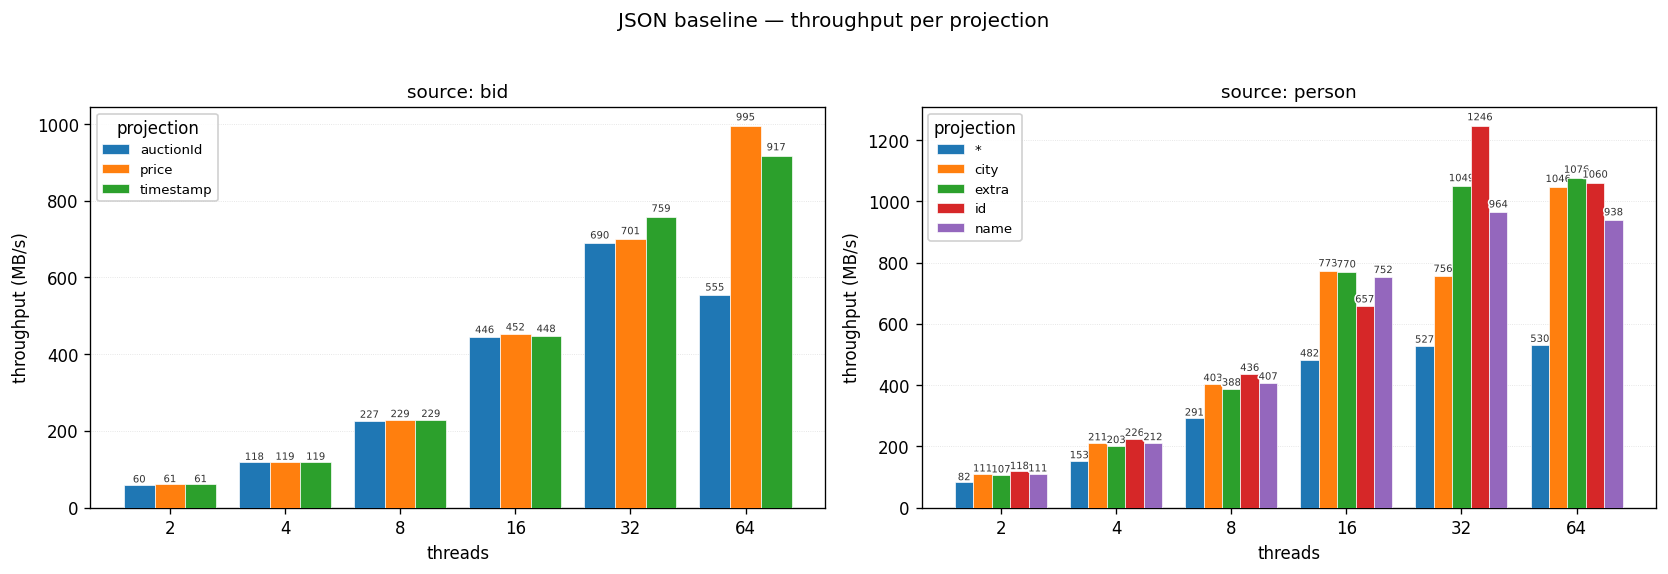

In [9]:
import matplotlib.patheffects as pe

fig, axes = plt.subplots(1, len(sources), figsize=(7 * len(sources), 4.6), dpi=120)
if len(sources) == 1:
    axes = [axes]

for ax, src in zip(axes, sources):
    sub = df[df.source == src]
    projections = sorted(sub.projection.unique())
    n = len(projections)
    x = np.arange(len(thread_counts))
    bar_w = 0.8 / n
    for i, proj in enumerate(projections):
        vals = (sub[sub.projection == proj]
                  .groupby("threads")["throughput_MBs"].median()
                  .reindex(thread_counts))
        offset = (i - (n - 1) / 2) * bar_w
        bars = ax.bar(x + offset, vals.values, bar_w,
                      label=proj, color=palette[i % len(palette)],
                      edgecolor="white", linewidth=0.4, zorder=3)
        for bar in bars:
            h = bar.get_height()
            if h is not None and not np.isnan(h):
                txt = ax.text(bar.get_x() + bar.get_width() / 2, h * 1.01,
                              f"{h:.0f}", ha="center", va="bottom",
                              fontsize=6, color="#333", fontweight="medium")
                txt.set_path_effects([pe.withStroke(linewidth=2, foreground="white")])
    ax.set_xticks(x)
    ax.set_xticklabels(thread_counts)
    ax.set_title(f"source: {src}")
    ax.set_xlabel("threads")
    ax.set_ylabel("throughput (MB/s)")
    ax.grid(True, axis="y", linestyle=":", alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.legend(title="projection", fontsize=8, frameon=True, framealpha=0.9)

fig.suptitle("JSON baseline — throughput per projection", y=1.03)
fig.tight_layout()
plt.show()

### Throughput summary table (MB/s)

In [10]:
tp_pivot = (df.pivot_table(index=["source", "projection"],
                           columns="threads",
                           values="throughput_MBs",
                           aggfunc="median")
              .reindex(columns=thread_counts))
tp_pivot.round(1)

threads               2      4      8      16      32      64
source projection                                            
bid    auctionId    60.1  118.2  226.9  445.5   689.6   555.3
       price        60.8  118.6  228.6  452.3   700.6   994.6
       timestamp    60.8  118.7  229.1  448.1   758.8   917.1
person *            82.4  153.3  291.2  482.2   527.0   529.5
       city        110.5  211.2  402.8  773.5   755.6  1046.1
       extra       107.4  202.5  388.1  770.1  1048.8  1076.0
       id          118.2  225.8  435.8  657.1  1245.7  1060.4
       name        110.7  211.8  407.4  751.9   964.0   938.5

## Projection overhead ratio
Exec time normalized to the cheapest projection of the same source at the same thread count.

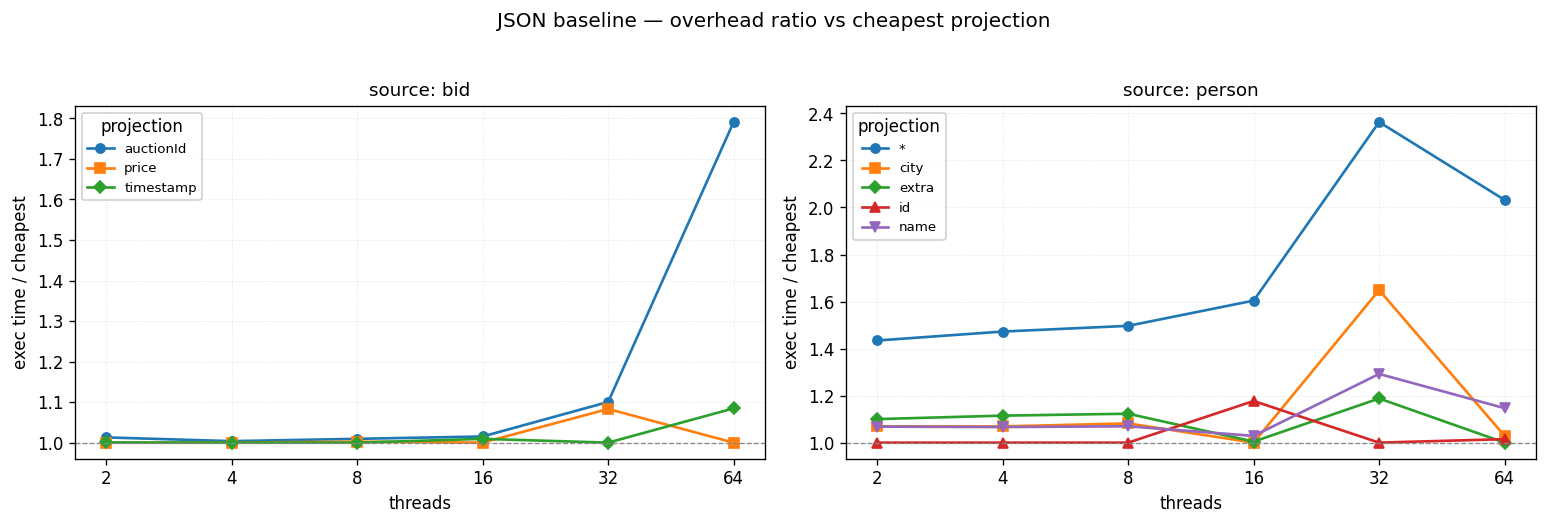

In [11]:
med = (df.groupby(["source", "projection", "threads"])["exec_time_s"]
         .median().reset_index())
cheapest = med.groupby(["source", "threads"])["exec_time_s"].transform("min")
med["ratio"] = med["exec_time_s"] / cheapest

fig, axes = plt.subplots(1, len(sources), figsize=(6.5 * len(sources), 4.2), dpi=120, sharex=True)
if len(sources) == 1:
    axes = [axes]

for ax, src in zip(axes, sources):
    sub = med[med.source == src]
    for i, proj in enumerate(sorted(sub.projection.unique())):
        d = sub[sub.projection == proj].sort_values("threads")
        ax.plot(d.threads, d.ratio,
                marker=markers[i % len(markers)], markersize=5.5, linewidth=1.6,
                color=palette[i % len(palette)], label=proj)
    ax.axhline(1.0, color="#888", linestyle="--", linewidth=0.8)
    ax.set_xscale("log", base=2)
    ax.set_xticks(thread_counts)
    ax.set_xticklabels(thread_counts)
    ax.set_title(f"source: {src}")
    ax.set_xlabel("threads")
    ax.set_ylabel("exec time / cheapest")
    ax.grid(True, linestyle=":", alpha=0.4)
    ax.legend(title="projection", fontsize=8, frameon=True, framealpha=0.9)

fig.suptitle("JSON baseline — overhead ratio vs cheapest projection", y=1.03)
fig.tight_layout()
plt.show()

## Summary table — median exec time (s)

In [12]:
pivot = (df.pivot_table(index=["source", "projection"],
                        columns="threads",
                        values="exec_time_s",
                        aggfunc="median")
           .reindex(columns=thread_counts))
pivot.round(3)

threads                 2        4       8       16      32      64
source projection                                                  
bid    auctionId   252.106  128.093  66.722  33.988  21.958  27.267
       price       248.898  127.645  66.254  33.479  21.613  15.224
       timestamp   249.012  127.623  66.103  33.790  19.956  16.512
person *            15.058    8.091   4.261   2.573   2.354   2.343
       city         11.226    5.874   3.080   1.604   1.642   1.186
       extra        11.549    6.126   3.197   1.611   1.183   1.153
       id           10.498    5.495   2.847   1.888   0.996   1.170
       name         11.212    5.859   3.045   1.650   1.287   1.322